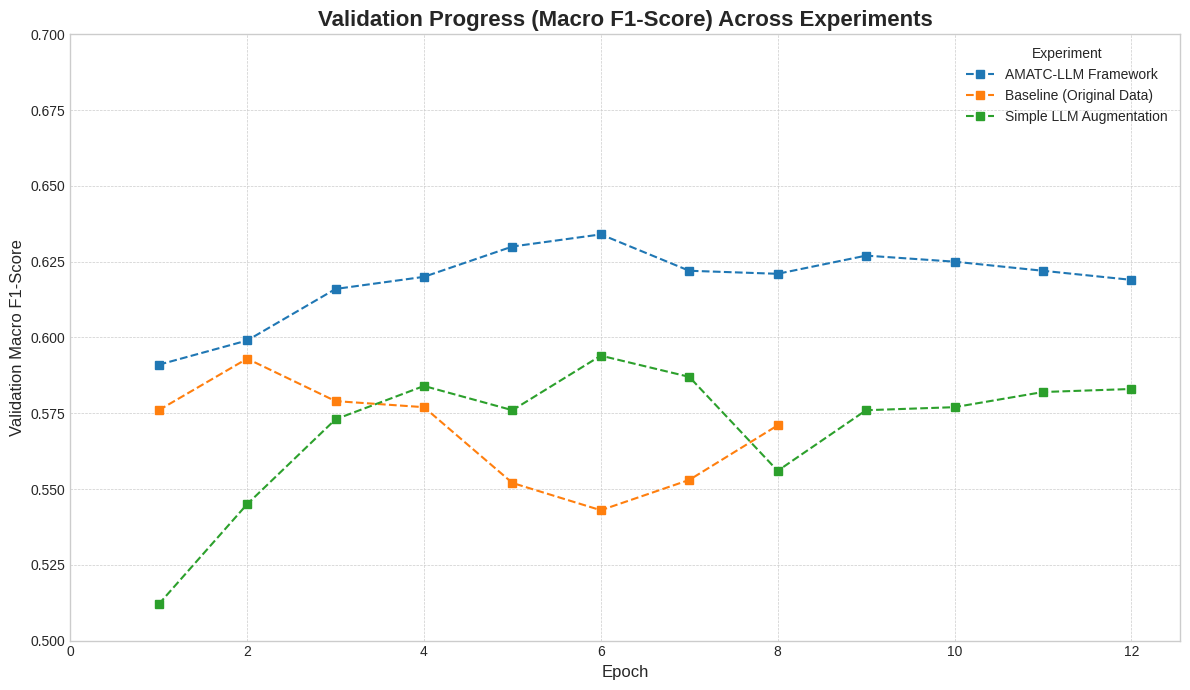

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Main Script ---

# Helper function to truncate floats to a specific number of decimal places
def truncate(n, decimals=0):
    multiplier = 10 ** decimals
    return int(n * multiplier) / multiplier

# Directly create DataFrames for each experiment's validation data.
baseline_scores = [0.576642, 0.593967, 0.579739, 0.577616, 0.552914, 0.543723, 0.553397, 0.571146]
simple_aug_scores = [0.512946, 0.545030, 0.573216, 0.584861, 0.576222, 0.594787, 0.587188, 0.556607, 0.576948, 0.577334, 0.582674, 0.583283]
amatc_scores = [0.591648, 0.599639, 0.616417, 0.620650, 0.630578, 0.634150, 0.622732, 0.621781, 0.627723, 0.625938, 0.622230, 0.619101]


baseline_data = {
    'Epoch': list(range(1, len(baseline_scores) + 1)),
    'Validation Macro F1': [truncate(s, 3) for s in baseline_scores],
    'Experiment': 'Baseline (Original Data)'
}
df_baseline = pd.DataFrame(baseline_data)

simple_aug_data = {
    'Epoch': list(range(1, len(simple_aug_scores) + 1)),
    'Validation Macro F1': [truncate(s, 3) for s in simple_aug_scores],
    'Experiment': 'Simple LLM Augmentation'
}
df_simple_aug = pd.DataFrame(simple_aug_data)

amatc_data = {
    'Epoch': list(range(1, len(amatc_scores) + 1)),
    'Validation Macro F1': [truncate(s, 3) for s in amatc_scores],
    'Experiment': 'AMATC-LLM Framework'
}
df_amatc = pd.DataFrame(amatc_data)


# Combine the data from all experiments into a single DataFrame.
all_data = pd.concat([df_baseline, df_simple_aug, df_amatc], ignore_index=True)

# --- Plotting ---

# Set a professional and clean plot style.
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Validation Progress Comparison
plt.figure(figsize=(12, 7))
for name, group in all_data.groupby('Experiment'):
    plt.plot(group['Epoch'], group['Validation Macro F1'], marker='s', linestyle='--', label=name)

plt.title('Validation Progress (Macro F1-Score) Across Experiments', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Macro F1-Score', fontsize=12)
plt.legend(title='Experiment', fontsize=10)
plt.xticks(np.arange(0, all_data['Epoch'].max() + 2, 2)) # Adjust x-axis ticks
plt.ylim(0.5, 0.7) # Set y-axis limits for better comparison
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


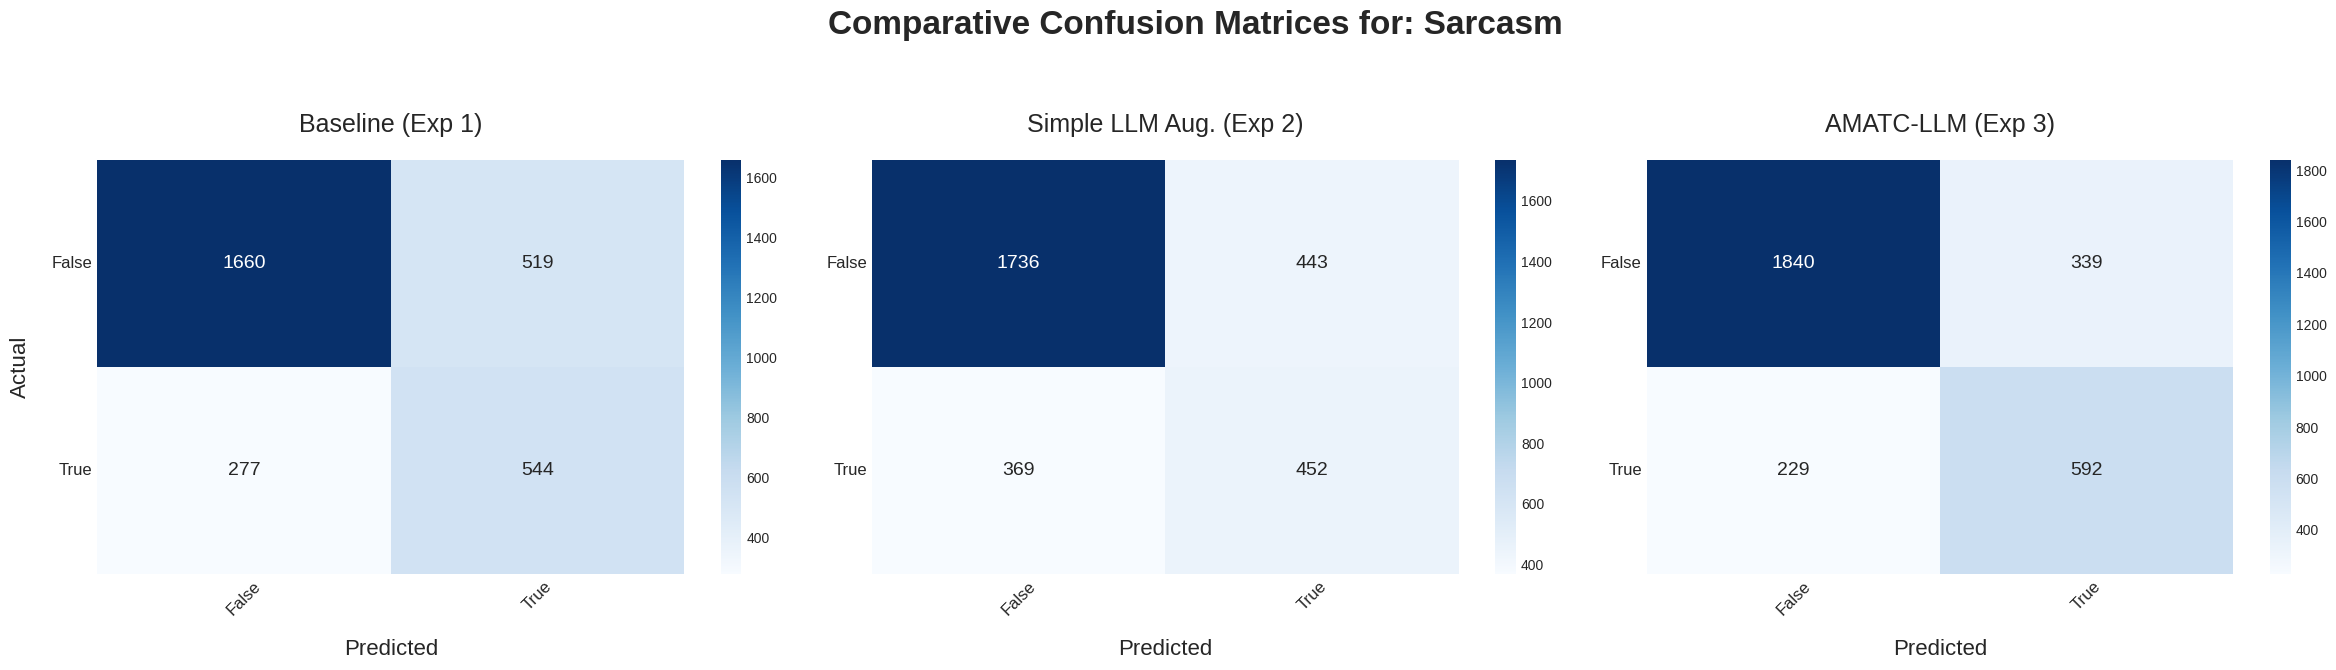

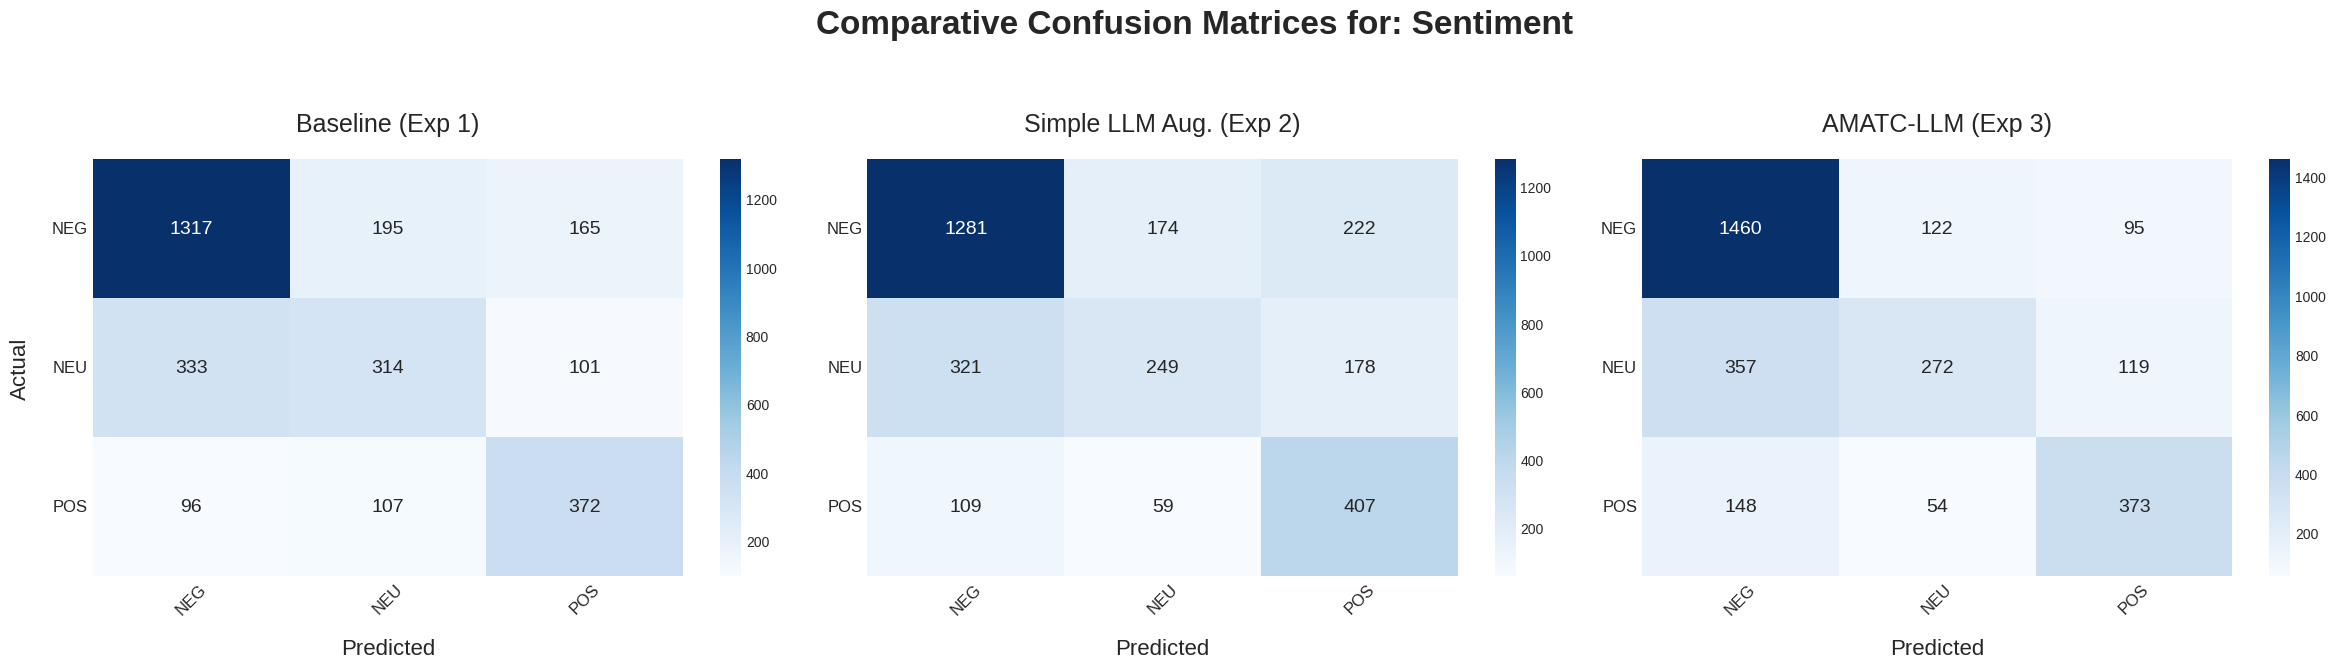

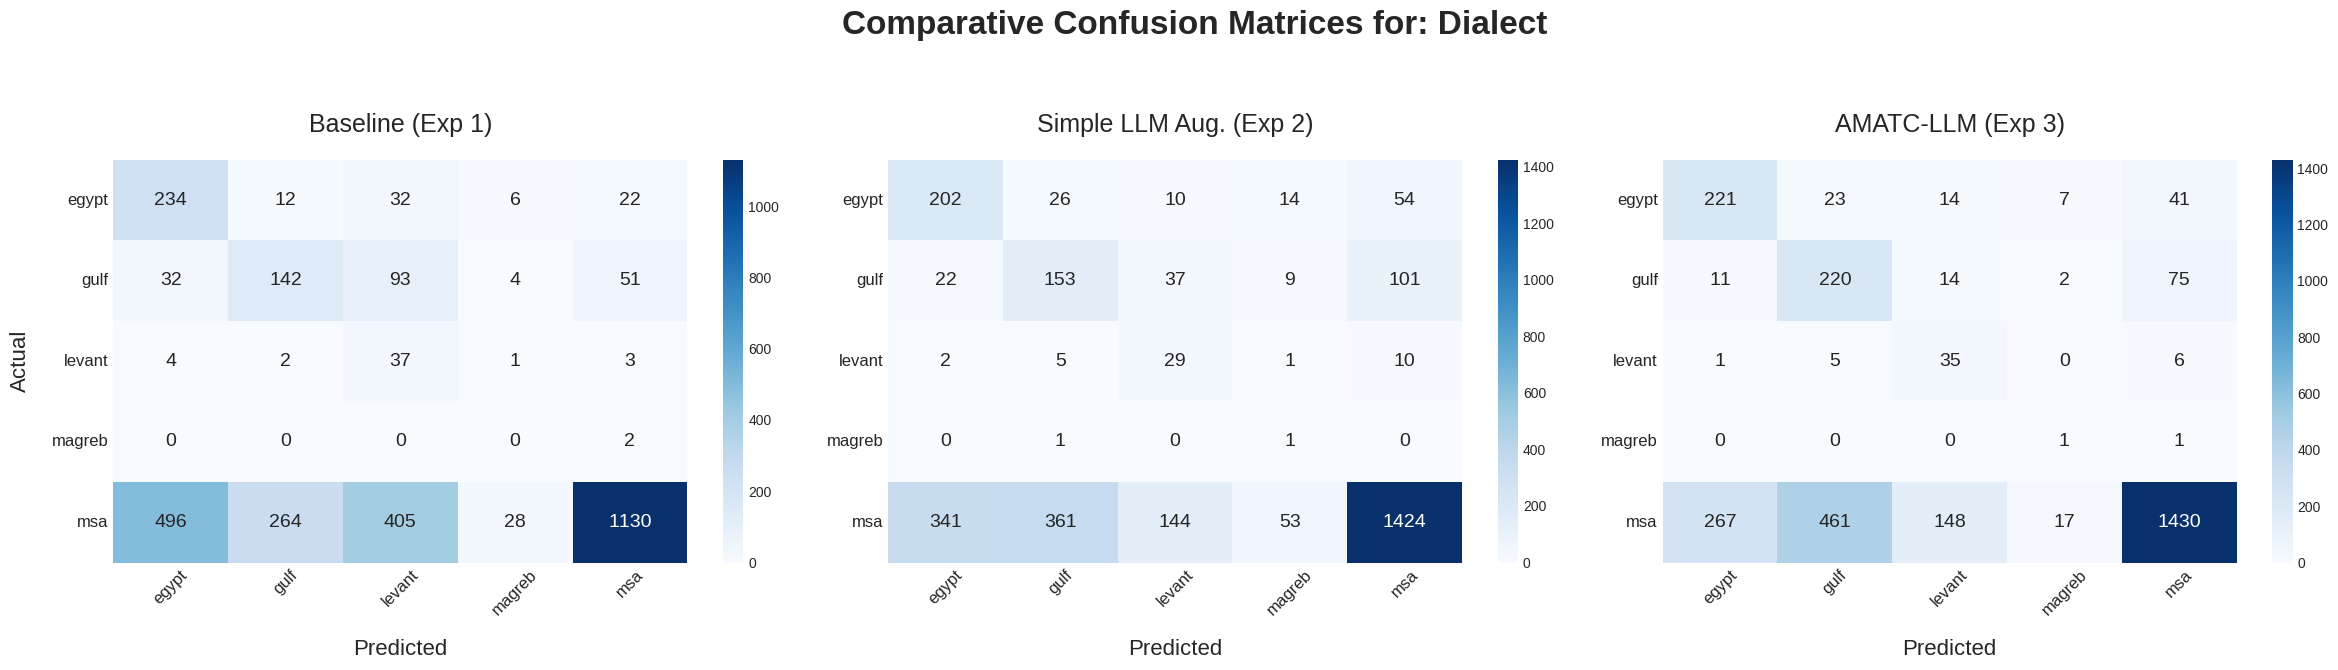

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sarcasm_labels = ['False', 'True']
sentiment_labels = ['NEG', 'NEU', 'POS']
dialect_labels = ['egypt', 'gulf', 'levant', 'magreb', 'msa']

all_matrices = {
    'Baseline (Exp 1)': {
        'Sarcasm': (np.array([[1660, 519], [277, 544]]), sarcasm_labels),
        'Sentiment': (np.array([[1317, 195, 165], [333, 314, 101], [96, 107, 372]]), sentiment_labels),
        'Dialect': (np.array([[234, 12, 32, 6, 22], [32, 142, 93, 4, 51], [4, 2, 37, 1, 3], [0, 0, 0, 0, 2], [496, 264, 405, 28, 1130]]), dialect_labels)
    },
    'Simple LLM Aug. (Exp 2)': {
        'Sarcasm': (np.array([[1736, 443], [369, 452]]), sarcasm_labels),
        'Sentiment': (np.array([[1281, 174, 222], [321, 249, 178], [109, 59, 407]]), sentiment_labels),
        'Dialect': (np.array([[202, 26, 10, 14, 54], [22, 153, 37, 9, 101], [2, 5, 29, 1, 10], [0, 1, 0, 1, 0], [341, 361, 144, 53, 1424]]), dialect_labels)
    },
    'AMATC-LLM (Exp 3)': {
        'Sarcasm': (np.array([[1840, 339], [229, 592]]), sarcasm_labels),
        'Sentiment': (np.array([[1460, 122, 95], [357, 272, 119], [148, 54, 373]]), sentiment_labels),
        'Dialect': (np.array([[221, 23, 14, 7, 41], [11, 220, 14, 2, 75], [1, 5, 35, 0, 6], [0, 0, 0, 1, 1], [267, 461, 148, 17, 1430]]), dialect_labels)
    }
}


tasks = ['Sarcasm', 'Sentiment', 'Dialect']
experiments = ['Baseline (Exp 1)', 'Simple LLM Aug. (Exp 2)', 'AMATC-LLM (Exp 3)']

for task in tasks:
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle(f'Comparative Confusion Matrices for: {task}', fontsize=24, fontweight='bold')

    for j, exp in enumerate(experiments):
        ax = axes[j]
        matrix_data, labels = all_matrices[exp][task]

        # Use seaborn to create a heatmap for the confusion matrix.
        sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    annot_kws={"size": 14}, cbar=True)

        # Set titles for each subplot (experiment).
        ax.set_title(exp, fontsize=18, pad=20)

        # Set shared y-label for the first plot in the row.
        if j == 0:
            ax.set_ylabel('Actual', fontsize=16, labelpad=15)

        ax.set_xlabel('Predicted', fontsize=16, labelpad=15)
        ax.tick_params(axis='x', labelsize=12, rotation=45)
        ax.tick_params(axis='y', labelsize=12, rotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92]) # Adjust layout for the main title.
    plt.show()


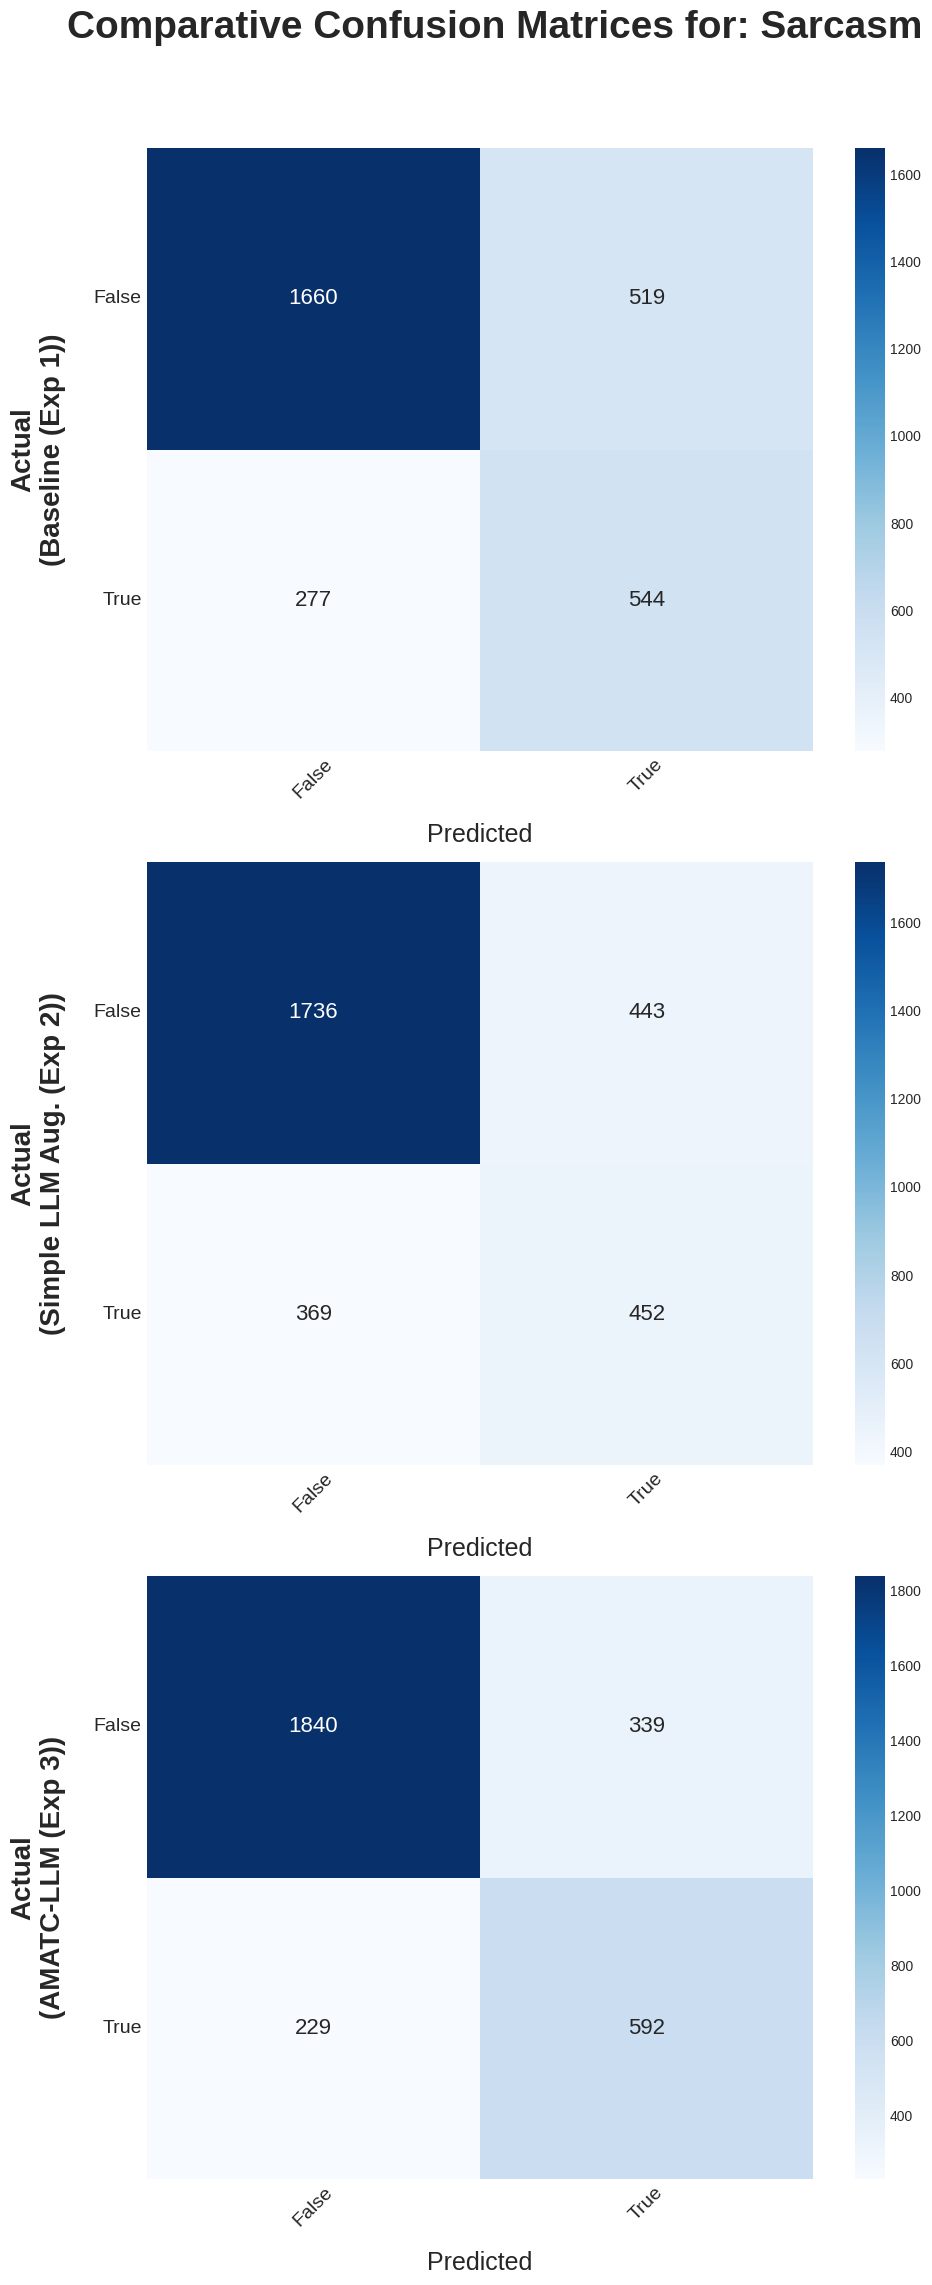

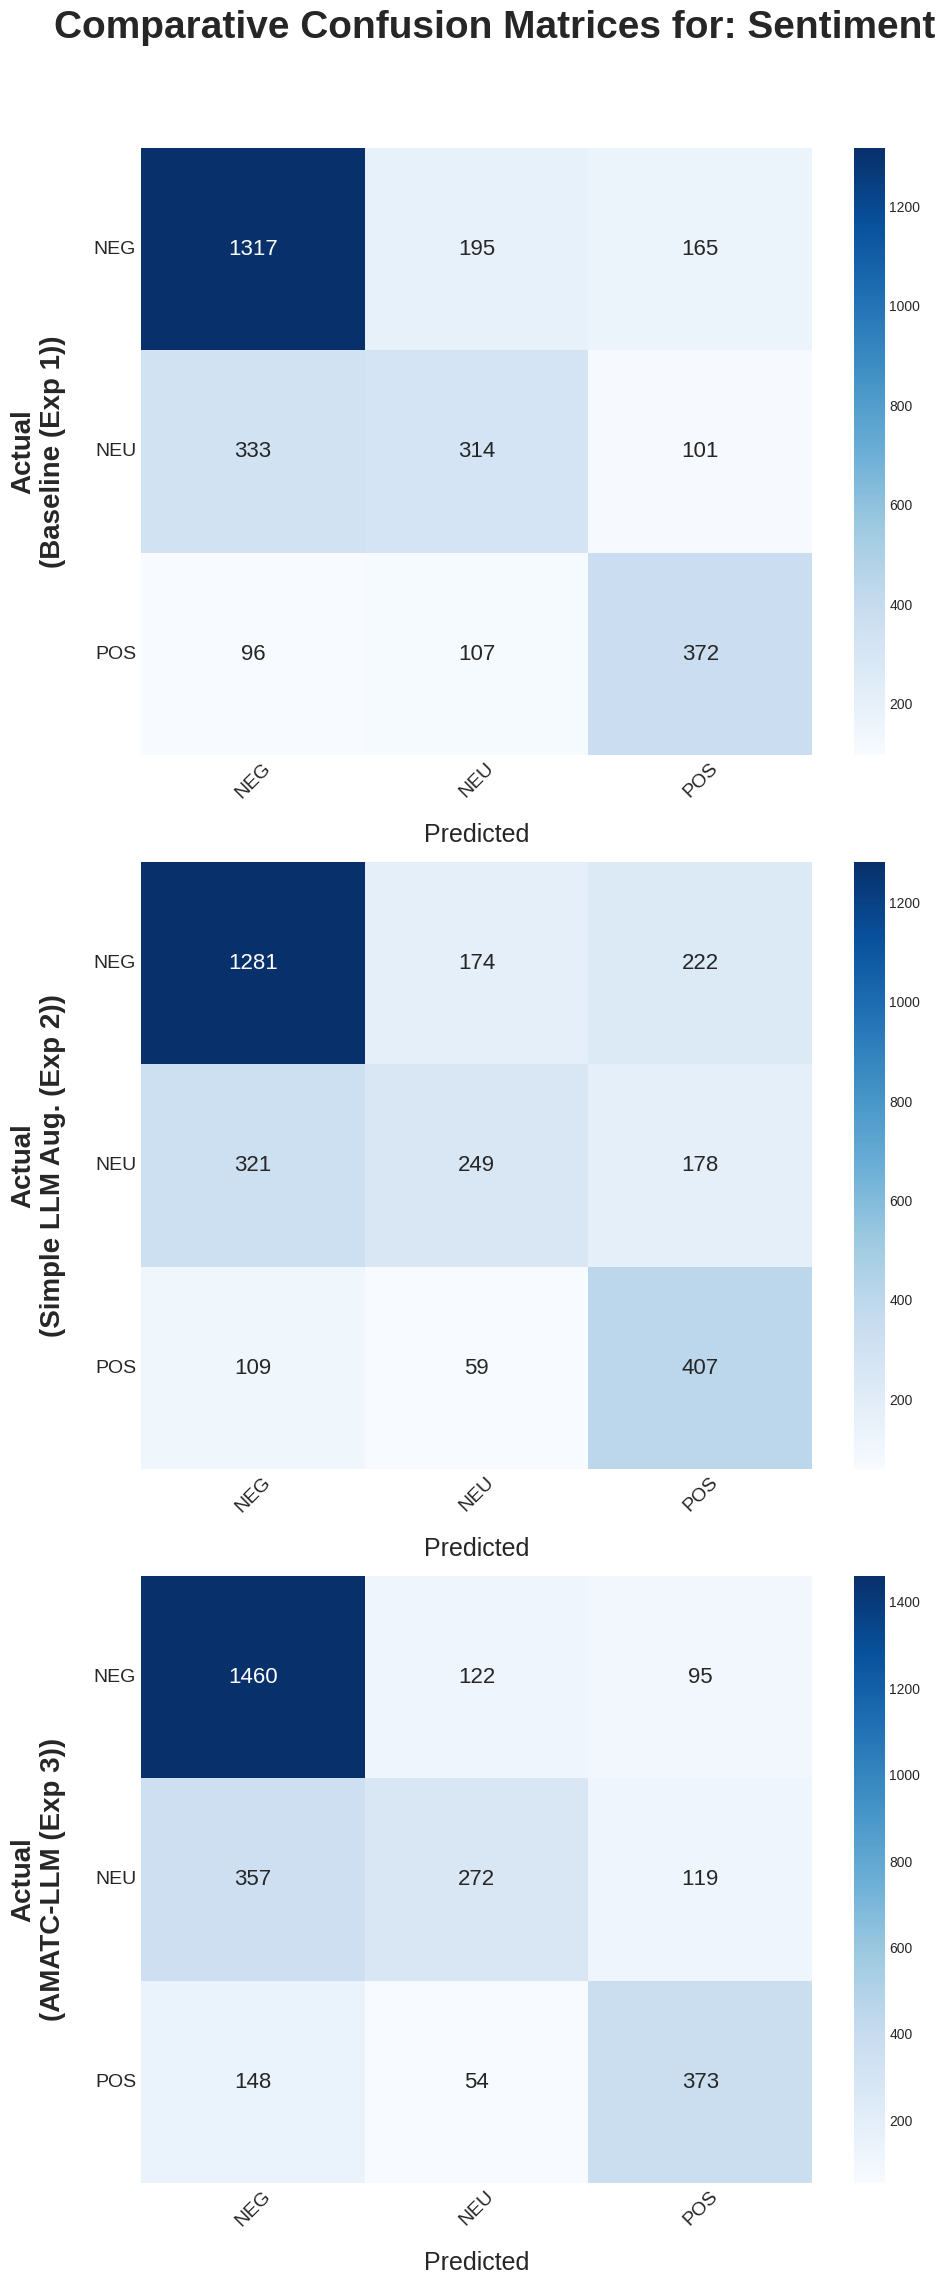

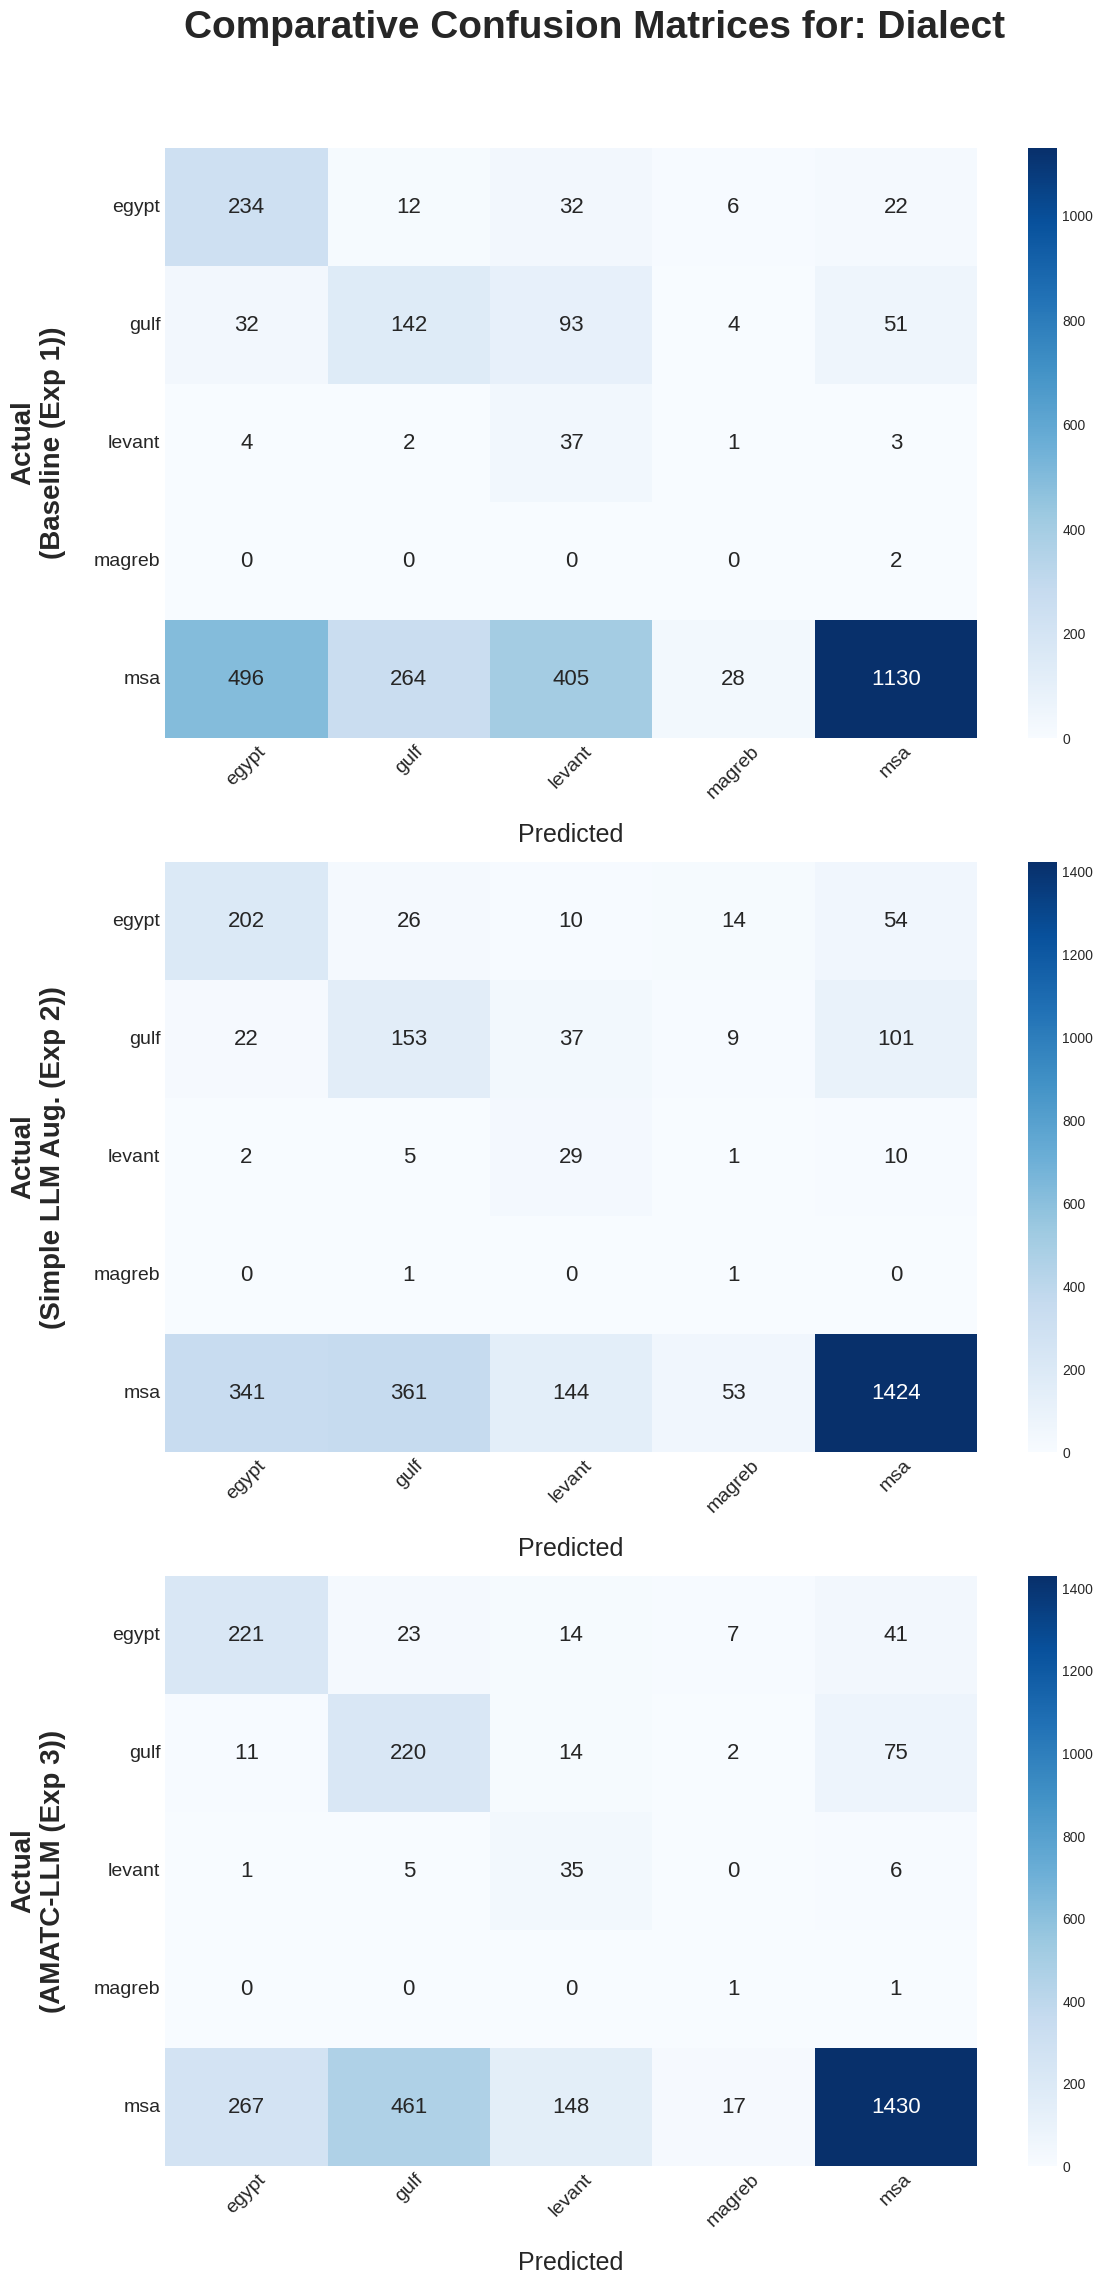

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Corrected Confusion Matrix Data ---
# Data for all three experiments is taken directly from the provided images.

# Labels for the classes in each task
sarcasm_labels = ['False', 'True']
sentiment_labels = ['NEG', 'NEU', 'POS']
dialect_labels = ['egypt', 'gulf', 'levant', 'magreb', 'msa']

# A nested dictionary holds the confusion matrix data and labels for each experiment and task.
all_matrices = {
    'Baseline (Exp 1)': {
        'Sarcasm': (np.array([[1660, 519], [277, 544]]), sarcasm_labels),
        'Sentiment': (np.array([[1317, 195, 165], [333, 314, 101], [96, 107, 372]]), sentiment_labels),
        'Dialect': (np.array([[234, 12, 32, 6, 22], [32, 142, 93, 4, 51], [4, 2, 37, 1, 3], [0, 0, 0, 0, 2], [496, 264, 405, 28, 1130]]), dialect_labels)
    },
    'Simple LLM Aug. (Exp 2)': {
        'Sarcasm': (np.array([[1736, 443], [369, 452]]), sarcasm_labels),
        'Sentiment': (np.array([[1281, 174, 222], [321, 249, 178], [109, 59, 407]]), sentiment_labels),
        'Dialect': (np.array([[202, 26, 10, 14, 54], [22, 153, 37, 9, 101], [2, 5, 29, 1, 10], [0, 1, 0, 1, 0], [341, 361, 144, 53, 1424]]), dialect_labels)
    },
    'AMATC-LLM (Exp 3)': {
        'Sarcasm': (np.array([[1840, 339], [229, 592]]), sarcasm_labels),
        'Sentiment': (np.array([[1460, 122, 95], [357, 272, 119], [148, 54, 373]]), sentiment_labels),
        'Dialect': (np.array([[221, 23, 14, 7, 41], [11, 220, 14, 2, 75], [1, 5, 35, 0, 6], [0, 0, 0, 1, 1], [267, 461, 148, 17, 1430]]), dialect_labels)
    }
}

# --- Plotting ---

tasks = ['Sarcasm', 'Sentiment', 'Dialect']
experiments = ['Baseline (Exp 1)', 'Simple LLM Aug. (Exp 2)', 'AMATC-LLM (Exp 3)']

# Loop through each task and create a separate, vertically-oriented figure for it.
for task in tasks:
    # Create a figure with 3 rows and 1 column of subplots.
    # Adjust figsize to be tall and narrow.
    fig_width = 10 if task != 'Dialect' else 12
    fig, axes = plt.subplots(3, 1, figsize=(fig_width, 24))
    fig.suptitle(f'Comparative Confusion Matrices for: {task}', fontsize=28, fontweight='bold')

    for i, exp in enumerate(experiments):
        ax = axes[i]
        matrix_data, labels = all_matrices[exp][task]

        # Use seaborn to create a heatmap for the confusion matrix.
        sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    annot_kws={"size": 16}, cbar=True)

        # Set the experiment name as the y-label for each row.
        ax.set_ylabel(f'Actual\n({exp})', fontsize=20, labelpad=20, fontweight='bold')

        ax.set_xlabel('Predicted', fontsize=18, labelpad=15)
        ax.tick_params(axis='x', labelsize=14, rotation=45)
        ax.tick_params(axis='y', labelsize=14, rotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for the main title.
    plt.show()


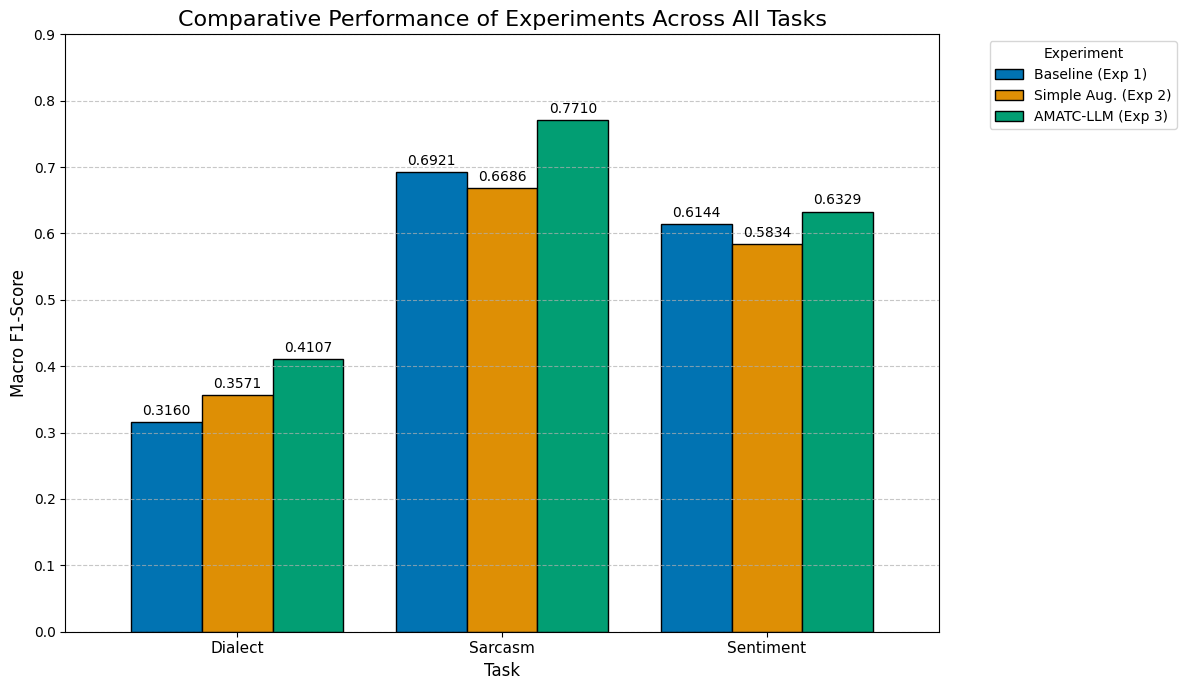

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data from the test results of the three experiments
data = {
    'Task': [
        'Sarcasm', 'Sarcasm', 'Sarcasm',
        'Sentiment', 'Sentiment', 'Sentiment',
        'Dialect', 'Dialect', 'Dialect'
    ],
    'Experiment': [
        'Baseline (Exp 1)', 'Simple Aug. (Exp 2)', 'AMATC-LLM (Exp 3)',
        'Baseline (Exp 1)', 'Simple Aug. (Exp 2)', 'AMATC-LLM (Exp 3)',
        'Baseline (Exp 1)', 'Simple Aug. (Exp 2)', 'AMATC-LLM (Exp 3)'
    ],
    'F1-Score': [
        0.6921, 0.6686, 0.7710,  # Sarcasm F1-Scores
        0.6144, 0.5834, 0.6329,  # Sentiment F1-Scores
        0.3160, 0.3571, 0.4107   # Dialect F1-Scores
    ]
}

df = pd.DataFrame(data)

# Pivot the DataFrame to get experiments as columns and tasks as the index
pivot_df = df.pivot(index='Task', columns='Experiment', values='F1-Score')

# Reorder columns to match the experiment number
pivot_df = pivot_df[['Baseline (Exp 1)', 'Simple Aug. (Exp 2)', 'AMATC-LLM (Exp 3)']]

# --- Color Customization using Seaborn ---
# Generate a professional, colorblind-friendly palette.
# You can change 'colorblind' to other palettes like 'pastel', 'muted', 'Set2', etc.
colors = sns.color_palette('colorblind', n_colors=3)

# Create the grouped bar chart using the custom colors
ax = pivot_df.plot(kind='bar',
                   figsize=(12, 7),
                   width=0.8,
                   edgecolor='black',
                   color=colors) # Use the seaborn color palette

# Add titles and labels
plt.title('Comparative Performance of Experiments Across All Tasks', fontsize=16)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.xlabel('Task', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 0.9)

# Add data labels on top of each bar for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=10, padding=3)

# Improve legend
ax.legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ensure layout is tight and save the figure
plt.tight_layout()
plt.savefig('comparative_performance_seaborn_colors.png')

plt.show()
